In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, accuracy_score, confusion_matrix, classification_report, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE
import seaborn as sns
from sklearn.linear_model import LogisticRegression


In [14]:
df = pd.read_csv(r'Lab dataset diabetes2.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
# Display basic information about the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"The dataset has {df.isnull().sum().sum()} missing values.")
print(f"The dataset has {df.duplicated().sum()} duplicated rows.")
print(f"The dataset has info", df.info())
print(f"The dataset has columns", df.columns)
print(f"The dataset has description", df.describe())


The dataset has 768 rows and 9 columns.
The dataset has 0 missing values.
The dataset has 0 duplicated rows.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
The dataset has info None
The dataset has columns Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
   

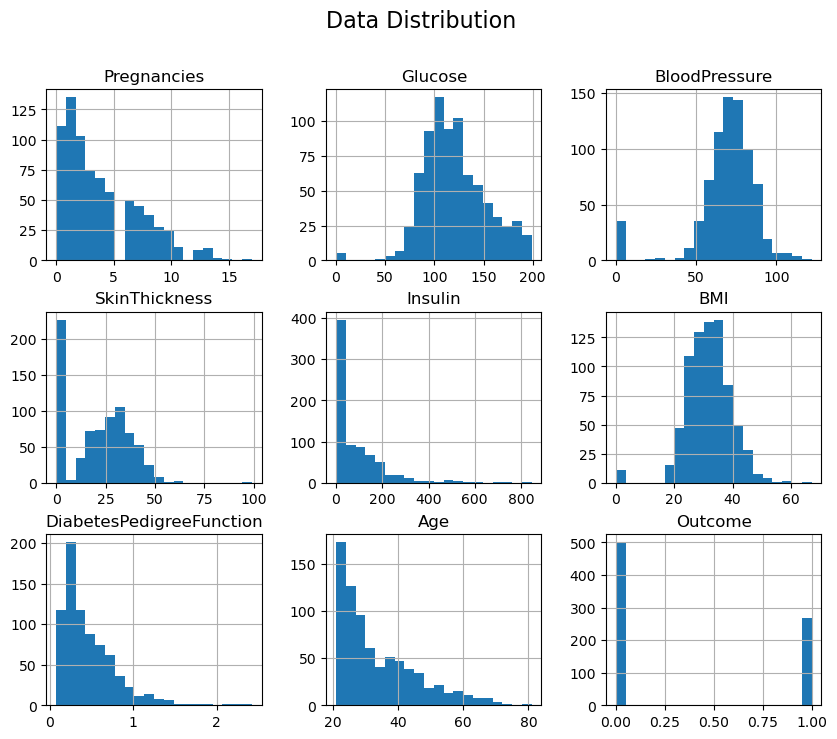

In [16]:
# Data Distribution
plt.Figure(figsize=(10, 5))
df.hist(figsize=(10, 8), bins=20)
plt.suptitle("Data Distribution", fontsize=16)
plt.show()

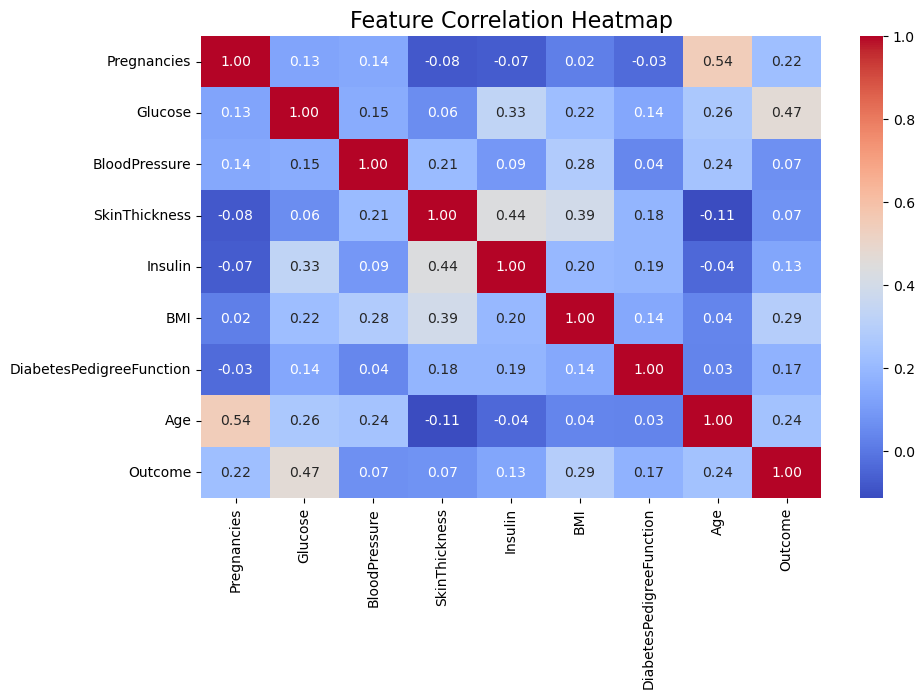

In [17]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

In [18]:
# Splitting Data into Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print(X.shape, y.shape)

(768, 8) (768,)


In [ ]:
# Splitting Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
# Model Training - Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [22]:
# Model Prediction
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [23]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC Score:", roc_auc)
print("classification_report:", classification_report(y_test, y_pred))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))


Accuracy: 0.7142857142857143
F1 Score: 0.56
Precision: 0.6086956521739131
Recall: 0.5185185185185185
ROC AUC Score: 0.8229629629629629
classification_report:               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

confusion_matrix: [[82 18]
 [26 28]]


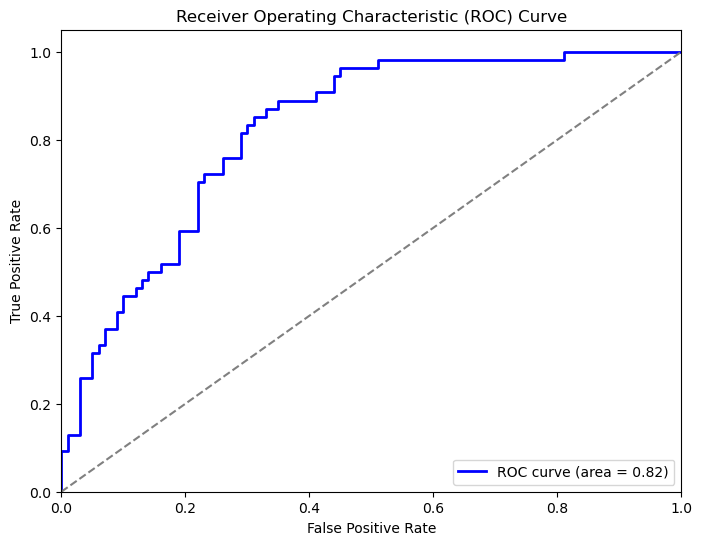

In [24]:
# ROC - AUC curve
fpr,tpr,_ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()